# Neural Networks Approach

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [56]:
import statsmodels.api as sm

In [57]:
import matplotlib.pyplot as plt

# Covid

In [58]:
df_covid = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/gold/covid_multivariate_w_2.csv')
df_covid.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [59]:
# create shifted cases (t+1)
df_covid['cases_1'] = df_covid.groupby('country')['new_cases'].shift(-1)


In [60]:
# numerical stamp for the datetime
df_covid["date"] = pd.to_datetime(df_covid["date"])

# drop rows where the shifted target is NaN (last day in each country)
df_covid = df_covid.dropna(subset=["cases_1"]).reset_index(drop=True)

In [61]:
df_original_covid = df_covid.copy()

In [62]:
selected_features_covid = ['date','country','cases_1', # target, date and country
                           'new_cases', 'google_symptom','o3', 'pop_vaccinated', 'no2', 'StringencyIndex_Average' ] # features



## NN

In [63]:
df = df_covid.copy()
df = df[selected_features_covid]
df.head()

,date,country,cases_1,new_cases,google_symptom,o3,pop_vaccinated,no2,StringencyIndex_Average
0,2020-03-23,Chile,2420.0,1558,32,10.619048,0.0,5.242857,69.844286
1,2020-03-30,Chile,2987.0,2420,28,13.771429,0.0,6.516667,75.930000
2,2020-04-06,Chile,3304.0,2987,25,12.733333,0.0,6.992857,75.930000
3,2020-04-13,Chile,4054.0,3304,21,11.707143,0.0,8.771429,75.930000
4,2020-04-20,Chile,7431.0,4054,21,11.769048,0.0,6.788095,75.930000


In [65]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K          # to clear memory
# ------------------------------------------------------------------
# 0.  Network builder
# ------------------------------------------------------------------
def build_ffn(input_dim: int):
    model = Sequential([
        Dense(128, activation="relu", input_shape=(input_dim,)),
        Dense(64,  activation="relu"),
        Dense(32,  activation="relu"),
        Dense(16,  activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# ------------------------------------------------------------------
# 1.  Loop over countries
# ------------------------------------------------------------------
target       = "cases_1"
countries    = df_covid["country"].unique()

metrics      = {}                   # {country: {"rmse":…, "r2":…}}
pred_series  = {}                   # {country: pd.Series(pred, index=date)}

for ctry in countries:
    df_nn = df_covid[df_covid["country"] == ctry].copy()
    if df_nn.empty:
        continue

    # ----- keep original date for indexing; also numeric for model -----

    df_nn.reset_index(inplace=True, drop=True) # for spliting
    predictors = [col for col in selected_features_covid if col not in ['date', 'country']]

    # ----- temporal split -----
    split_point  = int(0.80 * len(df_nn))
    idx_trainval = np.arange(split_point)
    idx_test     = np.arange(split_point, len(df_nn))

    X_train_val = df_nn.loc[idx_trainval, predictors].astype("float32").values
    X_test      = df_nn.loc[idx_test,      predictors].astype("float32").values

    y_train_val = df_nn.loc[idx_trainval, target].values.astype("float32").reshape(-1, 1)
    y_test      = df_nn.loc[idx_test,      target].values.astype("float32").reshape(-1, 1)

    # ----- train-val split -----

    X_tr, X_val, y_tr, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, shuffle = True)


    # ----- scaling -----
    X_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr)

    X_tr_sc, X_val_sc, X_test_sc = map(X_scaler.transform,
                                       (X_tr, X_val, X_test))
    y_tr_sc, y_val_sc = map(y_scaler.transform, (y_tr, y_val))

    # ----- model -----
    model = build_ffn(len(predictors))
    es    = EarlyStopping(monitor="val_loss",
                          patience=10, restore_best_weights=True)
    model.fit(
        X_tr_sc, y_tr_sc,
        epochs=1000,
        batch_size=8,
        validation_data=(X_val_sc, y_val_sc),
        shuffle=False,
        callbacks=[es],
        verbose=0
    )

    # ----- evaluate on *test* -----
    y_pred_test_sc = model.predict(X_test_sc, verbose=0)
    y_pred_test    = y_scaler.inverse_transform(y_pred_test_sc).flatten()

    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_test))
    r2   = r2_score(y_test.flatten(), y_pred_test)
    metrics[ctry] = {"rmse": rmse, "r2": r2}

    # ----- predict FULL series (train+test) -----
    X_full_sc = X_scaler.transform(df_nn[predictors].astype("float32").values)
    y_pred_full_sc = model.predict(X_full_sc, verbose=0)
    y_pred_full    = y_scaler.inverse_transform(y_pred_full_sc).flatten()

    pred_series[ctry] = pd.Series(y_pred_full,
                                  index=df_nn["date"],
                                  name=ctry)

    K.clear_session()   # free GPU/CPU graph memory

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

In [66]:
# ------------------------------------------------------------------
# 2.  Collect predictions into one DataFrame
# ------------------------------------------------------------------
pred_df = pd.concat(pred_series.values(), axis=1)
# columns already named by the series; index = dates
print(pred_df.head())
print("\nMetrics:\n", pd.DataFrame(metrics).T)


                  Chile     Colombia         Italy        Mexico            US
date                                                                          
2020-03-23  6093.791504 -1780.360352  30003.316406  10572.020508  273915.59375
2020-03-30  2423.451416 -1279.208008  32927.011719   3509.645020  230563.09375
2020-04-06  3420.029541 -1290.793945  26847.363281   5416.953613  196759.53125
2020-04-13  7227.117676  -952.348694  24882.613281   9079.852539  200239.46875
2020-04-20  8814.203125  1236.131836  21721.800781  11613.067383  193083.53125

Metrics:
                    rmse        r2
Chile       5798.471523  0.888798
Colombia    6415.655228  0.418926
Italy      52569.285025  0.888631
Mexico      9368.992262  0.973528
US        132760.961973  0.646129


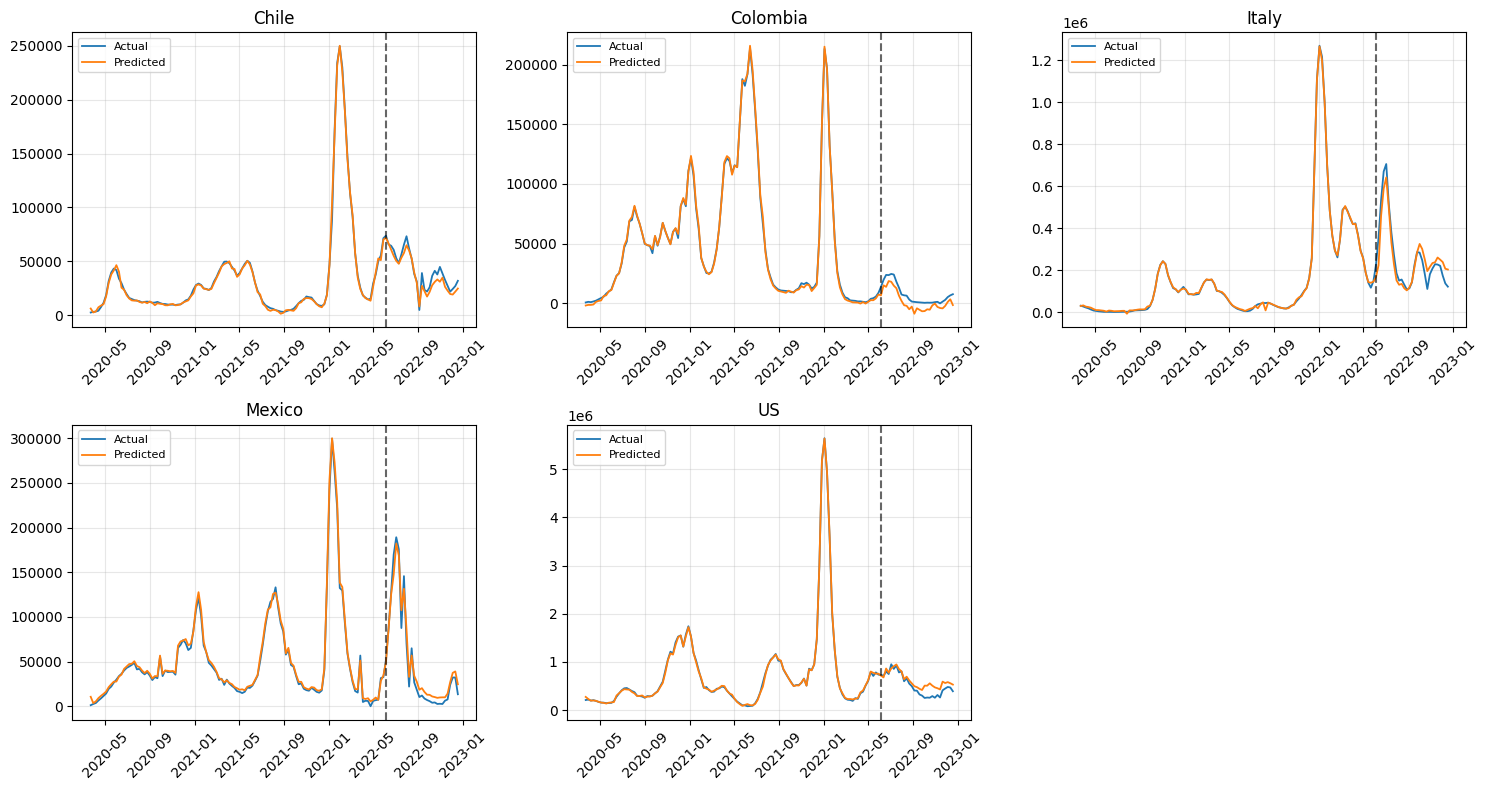

In [67]:
import math
# ------------------------------------------------------------------
# 3.  Plot actual vs. predicted for every country
# ------------------------------------------------------------------
n_countries = len(countries)
n_cols      = math.ceil(n_countries / 2)
fig, axes   = plt.subplots(2, n_cols,
                           figsize=(5 * n_cols, 8),
                           sharex=False, sharey=False)
axes = axes.flatten()

for i, ctry in enumerate(countries):
    ax = axes[i]

    # data for this country
    df_country = (df_covid[df_covid["country"] == ctry]
                  .sort_values("date"))
    dates      = pd.to_datetime(df_country["date"])
    actual     = df_country[target].values
    preds      = pred_df[ctry].loc[dates].values

    # plot series
    ax.plot(dates, actual, label="Actual", linewidth=1.3)
    ax.plot(dates, preds,  label="Predicted", linewidth=1.3)

    # vertical line at train‑test split
    split_date = dates.iloc[int(0.80 * len(dates))]
    ax.axvline(split_date, color="k", linestyle="--", alpha=0.6)

    ax.set_title(ctry)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    # -------- rotate x‑ticks 45 degrees ----------
    ax.tick_params(axis="x", labelrotation=45)

# hide any unused sub‑axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

In [68]:
from google.colab import files
# save and download pred_df as csv
pred_df.to_csv('DNN_covid.csv')
files.download('DNN_covid.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Epidemics

In [86]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K


In [87]:
df_epidemics = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/gold/epidemics.csv')

In [88]:
df_epidemics.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


In [89]:
df_epidemics['date'] = pd.to_datetime(df_epidemics['date'])

In [90]:
df_epidemics.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [91]:
# rename 'dengue', 'zika', 'chik', 'var'
df_epidemics.rename(columns={'dengue': 'dengue', 'zika': 'zika', 'chik': 'chikungunya', 'var': 'varicella'}, inplace=True)
# drop week column
df_epidemics.drop(columns=['week'], inplace=True)

In [92]:
# get shifted value for epidemics cumulative
df_epidemics['dengue_1'] = df_epidemics['dengue'].shift(-1)
df_epidemics['zika_1'] = df_epidemics['zika'].shift(-1)
df_epidemics['chikungunya_1'] = df_epidemics['chikungunya'].shift(-1)
df_epidemics['varicella_1'] = df_epidemics['varicella'].shift(-1)

In [93]:
# drop nans subset by shifted cumulative
df_epidemics.dropna(subset=['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1'], inplace=True)

In [94]:
df_epidemics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 195
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   dengue            196 non-null    int64         
 1   zika              196 non-null    float64       
 2   chikungunya       196 non-null    float64       
 3   varicella         196 non-null    float64       
 4   date              196 non-null    datetime64[ns]
 5   tavg              196 non-null    float64       
 6   tmin              196 non-null    float64       
 7   tmax              196 non-null    float64       
 8   prcp              196 non-null    float64       
 9   wdir              196 non-null    float64       
 10  wspd              196 non-null    float64       
 11  pres              196 non-null    float64       
 12  mob_index         196 non-null    float64       
 13  google_physician  196 non-null    int64         
 14  google_hospital   196 non-null 

In [95]:
# convert date to numeric
df_epidemics['date'] = pd.to_datetime(df_epidemics['date'])
df_epidemics['date_num'] = df_epidemics['date'].apply(lambda x: x.timestamp())

In [96]:
targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']

In [97]:
selected_features_epidemics = ['dengue', 'zika', 'chikungunya', 'varicella', 'dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1',
                               'pres','google_symptom', 'pm25', 'date', 'date_num']

In [98]:
df_epidemics_og = df_epidemics.copy()
df_epidemics = df_epidemics[selected_features_epidemics]

In [99]:
df_epidemics.head()

,dengue,zika,chikungunya,varicella,dengue_1,zika_1,chikungunya_1,varicella_1,pres,google_symptom,pm25,date,date_num
0,949,3.0,1.0,351.0,1006.0,1.0,4.0,275.0,1014.549139,44,118.285714,2020-03-23,1.584922e+09
1,1006,1.0,4.0,275.0,931.0,3.0,2.0,212.0,1013.957489,40,63.214286,2020-03-30,1.585526e+09
2,931,3.0,2.0,212.0,883.0,1.0,0.0,188.0,1014.803952,38,37.285714,2020-04-06,1.586131e+09
3,883,1.0,0.0,188.0,879.0,3.0,3.0,195.0,1016.499355,31,74.785714,2020-04-13,1.586736e+09
4,879,3.0,3.0,195.0,801.0,0.0,1.0,171.0,1015.642953,29,53.500000,2020-04-20,1.587341e+09


## NN

In [100]:
# -----------------------------------------------
# 0.  Configuration
# -----------------------------------------------
targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
date_col  = "date"

def build_ffn(d):
    m = Sequential([
        Dense(128, activation="relu", input_shape=(d,)),
        Dense(64,  activation="relu"),
        Dense(32,  activation="relu"),
        Dense(16,  activation="relu"),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

metrics   = {}                    # {target: {"rmse", "r2"}}
pred_dict = {}                    # {target: pd.DataFrame([date, pred])}

for tgt in targets:
    # --------------------- data prep ----------------------------
    df = df_epidemics.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df.sort_values(date_col, inplace=True)


    # ---------------------------------------------
    # 1.  Build the correct predictor list
    # ---------------------------------------------
    base_names = ["dengue", "zika", "chikungunya", "varicella"]

    # e.g. tgt = "dengue_cum_1"  →  base = "dengue",   own_base = "dengue_cum"
    base       = tgt.split("_")[0]
    own_base   = tgt.replace("_1", "")        # unshifted cumulative column

    # columns we must exclude
    exclude = {date_col, tgt}                 # drop date & the target itself

    for epi in base_names:
        cols_with_epi = [c for c in df.columns if c.startswith(epi)]
        if epi == base:
            # keep only own_base; drop every other transformation (raw, shifted, etc.)
            exclude.update([c for c in cols_with_epi if c != own_base])
        else:
            # drop all columns of other epidemics (raw + transforms)
            exclude.update(cols_with_epi)

    # final predictor list = every column not excluded
    predictors = [c for c in df.columns if c not in exclude]
    print(f"{tgt}: predictors -> {predictors}")

    # drop any row with NaN in target or predictor(s)
    df_clean = df.dropna(subset=[tgt] + predictors).reset_index(drop=True)
    if len(df_clean) < 10:
        print(f"{tgt}: skipped (too few complete rows)")
        continue

    # --------------------- split indices ------------------------
    split_pt     = int(0.80 * len(df_clean))
    idx_trainval = np.arange(split_pt)
    idx_test     = np.arange(split_pt, len(df_clean))

    train_idx, val_idx = train_test_split(
        idx_trainval, test_size=0.20, shuffle=True, random_state=42)
    train_idx.sort(); val_idx.sort()

    X_tr   = df_clean.loc[train_idx, predictors].values.astype("float32")
    X_val  = df_clean.loc[val_idx,  predictors].values.astype("float32")
    X_test = df_clean.loc[idx_test, predictors].values.astype("float32")

    y_tr   = df_clean.loc[train_idx, tgt].values.astype("float32").reshape(-1, 1)
    y_val  = df_clean.loc[val_idx,  tgt].values.astype("float32").reshape(-1, 1)
    y_test = df_clean.loc[idx_test, tgt].values.astype("float32").reshape(-1, 1)

    # --------------------- scaling ------------------------------
    X_scaler = StandardScaler().fit(X_tr)
    y_scaler = StandardScaler().fit(y_tr)

    X_tr_sc, X_val_sc, X_test_sc = map(X_scaler.transform,
                                       (X_tr, X_val, X_test))
    y_tr_sc, y_val_sc            = map(y_scaler.transform, (y_tr, y_val))

    # --------------------- model --------------------------------
    model = build_ffn(X_tr_sc.shape[1])
    es    = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    model.fit(
        X_tr_sc, y_tr_sc,
        epochs=1000,
        batch_size=8,
        validation_data=(X_val_sc, y_val_sc),
        shuffle=False,
        callbacks=[es],
        verbose=0
    )

    # --------------------- metrics ------------------------------
    y_pred_test = y_scaler.inverse_transform(
        model.predict(X_test_sc, verbose=0)).flatten()
    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_test))
    r2   = r2_score(y_test.flatten(), y_pred_test)
    metrics[tgt] = {"rmse": rmse, "r2": r2}

    # --------------------- full‑series prediction ---------------
    X_full_sc = X_scaler.transform(
        df_clean[predictors].values.astype("float32"))
    y_pred_full = y_scaler.inverse_transform(
        model.predict(X_full_sc, verbose=0)).flatten()

    pred_dict[tgt] = pd.DataFrame({
        date_col: df_clean[date_col].values,
        "pred":   y_pred_full
    })

    K.clear_session()

dengue_1: predictors -> ['dengue', 'pres', 'google_symptom', 'pm25', 'date_num']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


zika_1: predictors -> ['zika', 'pres', 'google_symptom', 'pm25', 'date_num']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


chikungunya_1: predictors -> ['chikungunya', 'pres', 'google_symptom', 'pm25', 'date_num']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


varicella_1: predictors -> ['varicella', 'pres', 'google_symptom', 'pm25', 'date_num']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
# --------------------------------------------------
# 1.  Stack predictions with a simple concat
# --------------------------------------------------
date_col = "date"            # make sure it's still defined

# convert each df to a Series indexed by date, then concat column‑wise
series_list = []
for tgt in targets:
    if tgt not in pred_dict:
        continue
    df_pred = pred_dict[tgt].rename(columns={"pred": tgt})
    s       = df_pred.set_index(date_col)[tgt]     # Series with Date index
    series_list.append(s)

pred_df = pd.concat(series_list, axis=1)           # dates as index, targets as columns
pred_df.sort_index(inplace=True)

print(pred_df.head())
print("\nTest metrics\n-------------")
print(pd.DataFrame(metrics).T)

              dengue_1    zika_1  chikungunya_1  varicella_1
date                                                        
2020-03-23  995.417603  1.396542       2.440722   243.629333
2020-03-30  921.057434  1.367093       1.246347   155.036087
2020-04-06  845.614563  1.577113       1.042698   147.734421
2020-04-13  858.832886  1.237660       1.408221   152.445435
2020-04-20  827.244507  1.263919       1.190263   144.732834

Test metrics
-------------
                     rmse        r2
dengue_1       481.847048  0.357282
zika_1           0.840599 -0.104072
chikungunya_1    1.119217 -0.046051
varicella_1     83.355273  0.716874


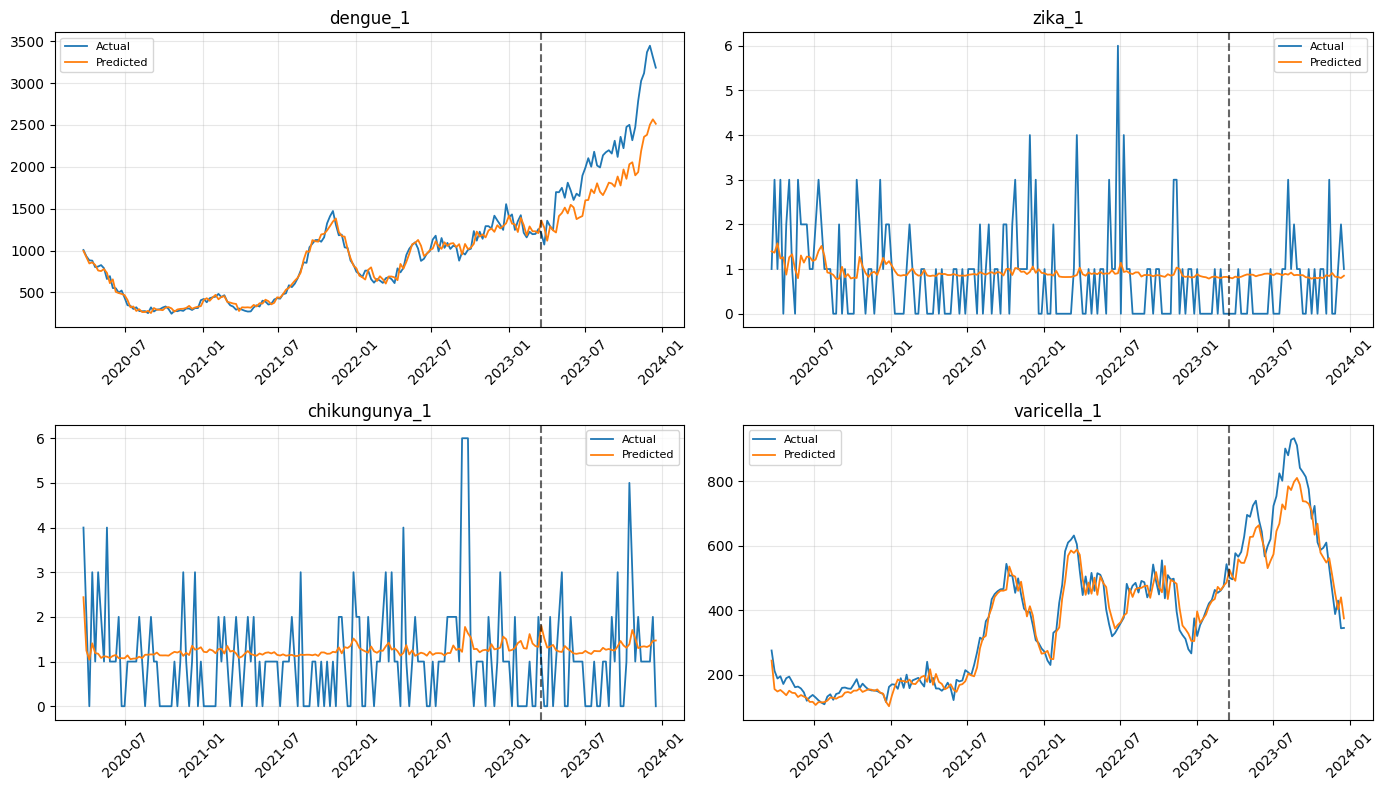

In [102]:
# -----------------------------------------------
# 2.  Plot 2 × 2 grid
# -----------------------------------------------
fig_rows = 2
fig_cols = math.ceil(len(targets) / 2)
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(14, 8))
axes = axes.flatten()

for i, tgt in enumerate(targets):
    if tgt not in pred_dict:
        continue
    ax = axes[i]

    df_act = df_epidemics[[date_col, tgt]].dropna().sort_values(date_col)
    dates  = df_act[date_col]
    actual = df_act[tgt].values
    preds  = pred_df[tgt].loc[dates].values

    ax.plot(dates, actual, label="Actual", linewidth=1.3)
    ax.plot(dates, preds,  label="Predicted", linewidth=1.3)

    split_date = dates.iloc[int(0.80 * len(dates))]
    ax.axvline(split_date, color="k", linestyle="--", alpha=0.6)

    ax.set_title(tgt)
    ax.tick_params(axis="x", labelrotation=45)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# hide any unused subplot slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

If only use date and self lagged variable, the model is way better, if use all predictors, there is too much variance

In [103]:
from google.colab import files
# save and download pred_df as csv
pred_df.to_csv('DNN_epidemics.csv')
files.download('DNN_epidemics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>